# INTRODUCTION

We are going to focus highly on genres. Lets know everything about Gebres.

Here are some things to look at:

# Research Questions (Q)

1. Which genres are the most common?
2. Which genres have high avg. budget and revenue?
2.5 Which genres have avg. profit?
3. Which genres have high avg. popularity?
4. Which genres have highest number of movies with an voting avg. >= 8?

# Research Hypotheses (H):

1. The best movies according to vote avg. return high profit and revenue.
2. The best movies according to popularity return high profit and revenue.
3. Highly budgetedd movies return high revenue and profit.
4. Highly budgeted movies have a high popularity.

In [109]:
import pandas as pd
from pandas import Series, DataFrame
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
movies = pd.read_csv(r'/Users/bilegjargalbattulga/Desktop/data analyst/Python for Dana Analysis/project 1/imdb_movies.csv')

In [94]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [95]:
pd.set_option('display.max.columns', 21)

In [96]:
movies.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.500000,2015,137999939.280026,1392445892.523800
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.100000,2015,137999939.280026,348161292.489031
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.300000,2015,101199955.472019,271619025.407628
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.500000,2015,183999919.040035,1902723129.801820
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.300000,2015,174799923.088033,1385748801.470520


## Preprocessing

In [97]:
#checking for duplicates
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
2090,42194,tt0411951,0.596430,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,martial arts|dystopia|based on video game|mart...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/10,110,5.000000,2010,30000000.000000,967000.000000


In [7]:
# removing duplicates
movies.drop_duplicates(inplace = True)
movies[movies.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


In [8]:
# Remove non-null values in column genre, because we dont need a data wehre genre is empty

In [9]:
movies.dropna(subset = ['genres'], inplace = True)

In [10]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10842 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10842 non-null  int64  
 1   imdb_id               10834 non-null  object 
 2   popularity            10842 non-null  float64
 3   budget                10842 non-null  int64  
 4   revenue               10842 non-null  int64  
 5   original_title        10842 non-null  object 
 6   cast                  10767 non-null  object 
 7   homepage              2931 non-null   object 
 8   director              10800 non-null  object 
 9   tagline               8036 non-null   object 
 10  keywords              9367 non-null   object 
 11  overview              10839 non-null  object 
 12  runtime               10842 non-null  int64  
 13  genres                10842 non-null  object 
 14  production_companies  9826 non-null   object 
 15  release_date       

In [12]:
movies['profit'] = movies['revenue'] - movies['budget']

In [14]:
# remove not related columns

In [118]:
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres', 'release_year', 'vote_count', 'vote_average', 'profit']]

In [17]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,1363528810
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,228436354
2,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,185238201
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,1868178225
4,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,1316249360


In [27]:
# 1 specifies the actual axis that we are working on (y).
    
movies_genre['genres'].str.split('|').apply(Series,1)

,0,1,2,3,4
0,Action,Adventure,Science Fiction,Thriller,NaN
1,Action,Adventure,Science Fiction,Thriller,NaN
2,Adventure,Science Fiction,Thriller,NaN,NaN
3,Action,Adventure,Science Fiction,Fantasy,NaN
4,Action,Crime,Thriller,NaN,NaN
...,...,...,...,...,...
10861,Documentary,NaN,NaN,NaN,NaN
10862,Action,Adventure,Drama,NaN,NaN
10863,Mystery,Comedy,NaN,NaN,NaN
10864,Action,Comedy,NaN,NaN,NaN


In [28]:
# stack them
movies_genre['genres'].str.split('|').apply(Series,1).stack()

0      0             Action
       1          Adventure
       2    Science Fiction
       3           Thriller
1      0             Action
                 ...       
10863  0            Mystery
       1             Comedy
10864  0             Action
       1             Comedy
10865  0             Horror
Length: 26955, dtype: object

In [119]:
split = movies_genre['genres'].str.split('|').apply(Series,1).stack()
split.index = split.index.droplevel(-1)

split.name = 'genres_split'
del movies_genre['genres']
movies_genre = movies_genre.join(split)

In [120]:
movies_genre

,popularity,budget,revenue,original_title,runtime,release_year,vote_count,vote_average,profit,genres_split
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,2015,6185,7.100000,228436354,Action
...,...,...,...,...,...,...,...,...,...,...
10863,0.065141,0,0,Beregis Avtomobilya,94,1966,11,6.500000,0,Mystery
10863,0.065141,0,0,Beregis Avtomobilya,94,1966,11,6.500000,0,Comedy
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,1966,22,5.400000,0,Action
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,1966,22,5.400000,0,Comedy


In [32]:
# lets filter where vote count is more than 50 because one vote will mislead...

1. Which genres are the most common?

In [49]:
genres_count = pd.DataFrame(movies_genre.groupby('genres_split').original_title.nunique()).sort_values('original_title', ascending = True)
genres_count

,original_title
genres_split,
Western,163
TV Movie,167
Foreign,188
War,269
History,331
Music,403
Documentary,520
Animation,697
Mystery,796


<Axes: title={'center': 'Movies Per Genre in %'}, ylabel='original_title'>

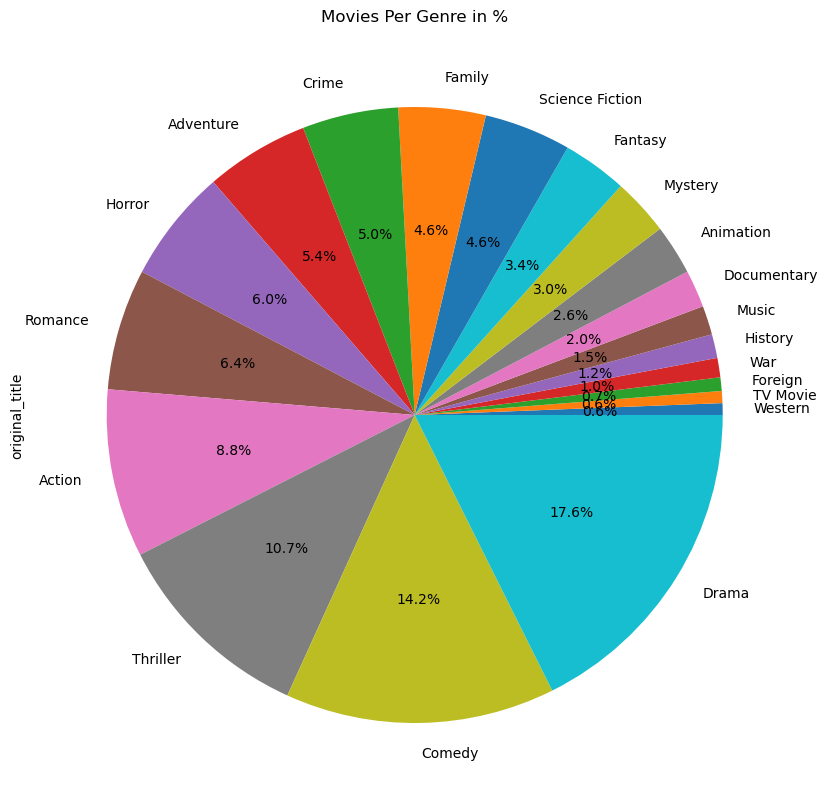

In [50]:
genres_count['original_title'].plot.pie(title = 'Movies Per Genre in %', autopct = '%1.1f%%', figsize = (10,10))

<Axes: title={'center': 'Movies Per Genre'}, ylabel='genres_split'>

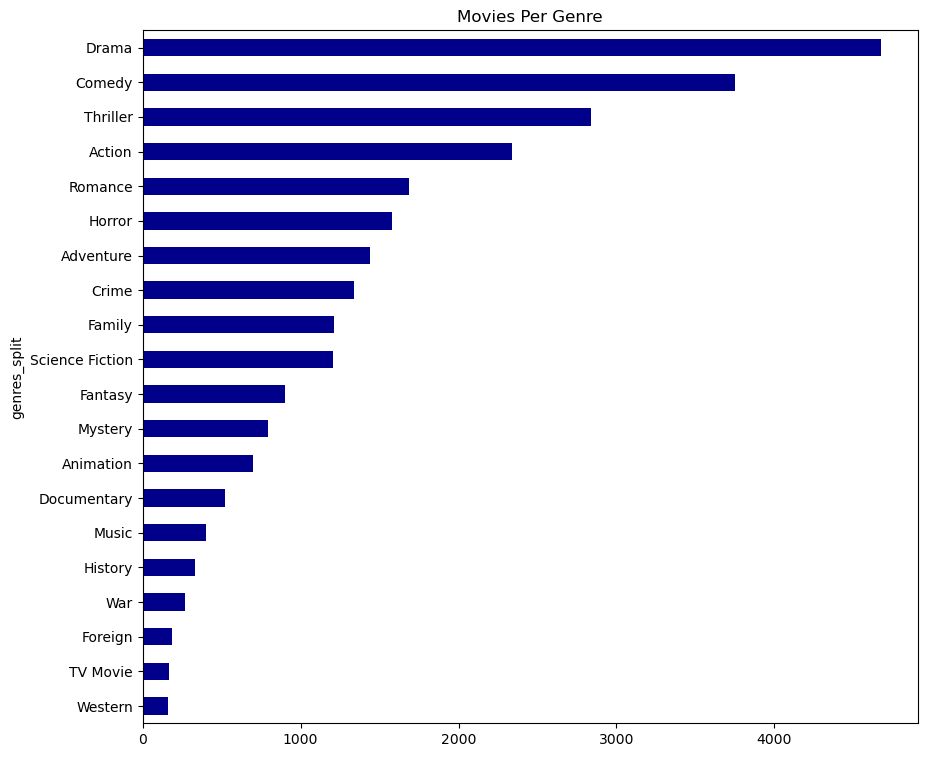

In [54]:
genres_count['original_title'].plot.barh(title = 'Movies Per Genre', color = 'darkblue', figsize = (10,9))

2. Which genres have high avg. budget and revenue?

In [59]:
genres_avg = movies_genre.groupby('genres_split').mean()
pd.options.display.float_format = '{:2f}'.format
genres_avg

/var/folders/mm/dk0qprd53tb6f0y8g20c97vr0000gn/T/ipykernel_72803/266373093.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  genres_avg = movies_genre.groupby('genres_split').mean()


,popularity,budget,revenue,runtime,vote_count,vote_average,profit
genres_split,,,,,,,
Action,0.926274,27727820.331376,72794732.002517,104.917785,392.993708,5.787752,45066911.671141
Adventure,1.154259,37543694.530931,113137861.069341,106.173351,513.125085,5.940585,75594166.538409
Animation,0.852182,23159781.606581,75256062.223176,68.181688,303.000000,6.403147,52096280.616595
Comedy,0.592607,13297915.618244,37526242.072238,96.745057,176.436330,5.905167,24228326.453994
Crime,0.744930,17663801.124815,42368661.645495,106.917282,278.805022,6.124889,24704860.520679
Documentary,0.181432,577149.148077,2041106.994231,102.651923,35.105769,6.908462,1463957.846154
Drama,0.591495,11880717.773529,29232255.725840,110.478151,182.544538,6.165546,17351537.952311
Family,0.786668,23359337.420796,72433176.373680,89.603574,272.320877,5.997563,49073838.952884
Fantasy,0.992840,32612585.348253,96313657.081878,100.736900,420.741266,5.863537,63701071.733624


In [62]:
genres_avg.sort_values('budget', ascending = True, inplace = True)

<Axes: title={'center': 'Budget and Revenue by Genre'}, ylabel='genres_split'>

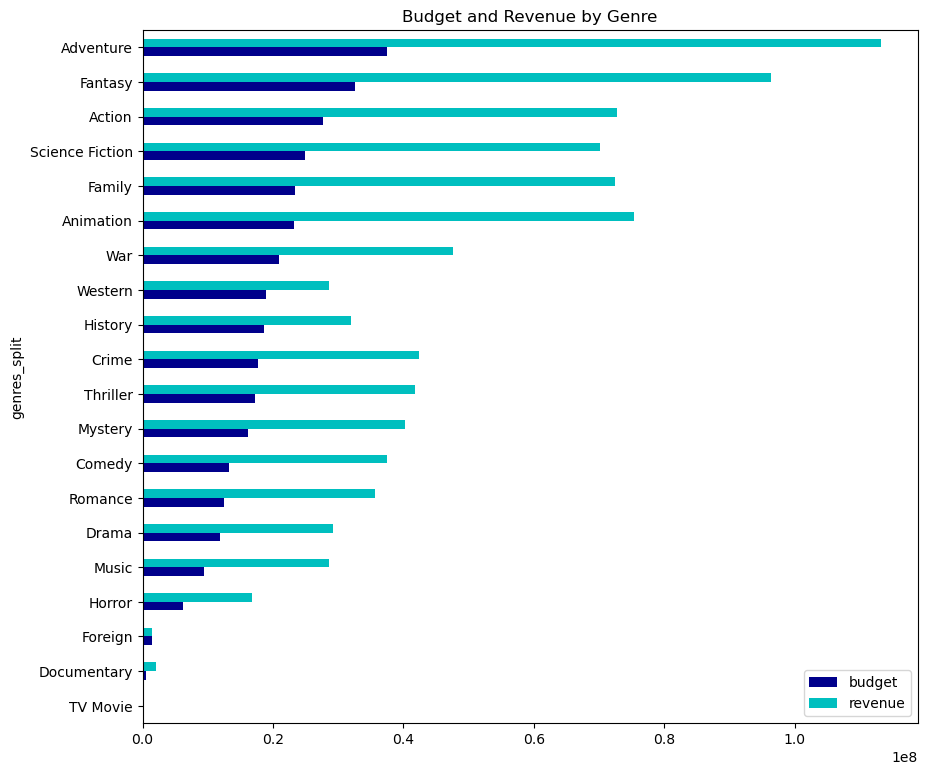

In [64]:
genres_avg[['budget', 'revenue']].plot.barh(title = 'Budget and Revenue by Genre', color = ('Darkblue', 'c'), figsize = (10,9))

2.5 Which genres have avg. profit?

In [66]:
genres_avg.sort_values('profit', ascending = True, inplace = True)

<Axes: title={'center': 'Profit by Genre'}, ylabel='genres_split'>

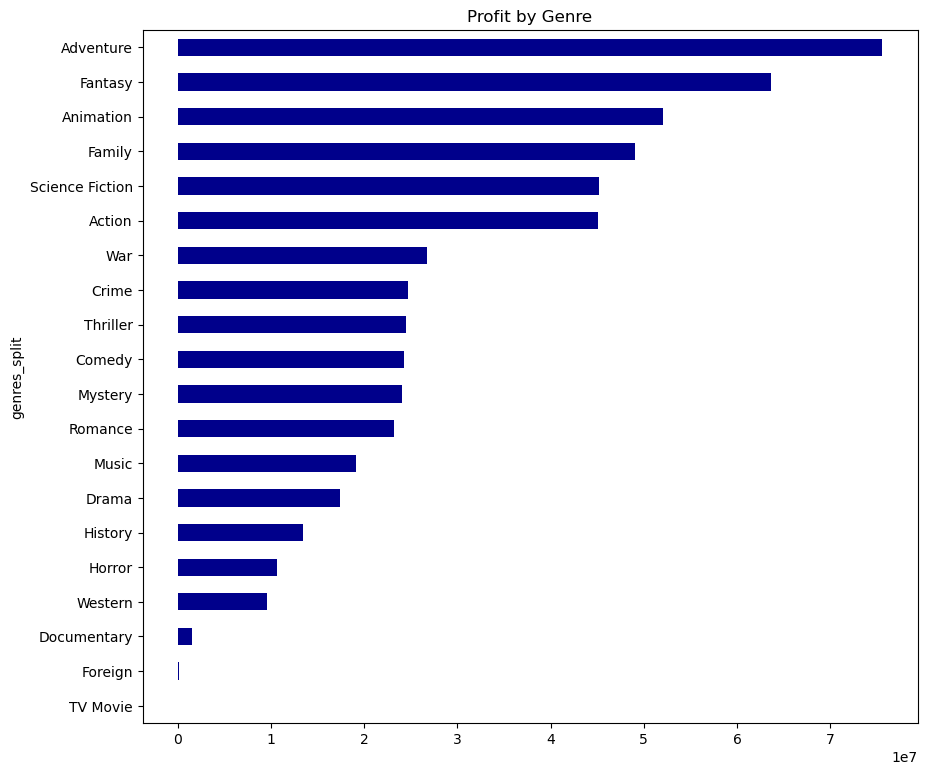

In [67]:
genres_avg['profit'].plot.barh(title = 'Profit by Genre', color = 'Darkblue', figsize = (10,9))

3. Which genres have high avg. popularity?

In [68]:
genres_avg.sort_values('popularity', ascending = True, inplace = True)

<Axes: title={'center': 'Popularity by Genre'}, ylabel='genres_split'>

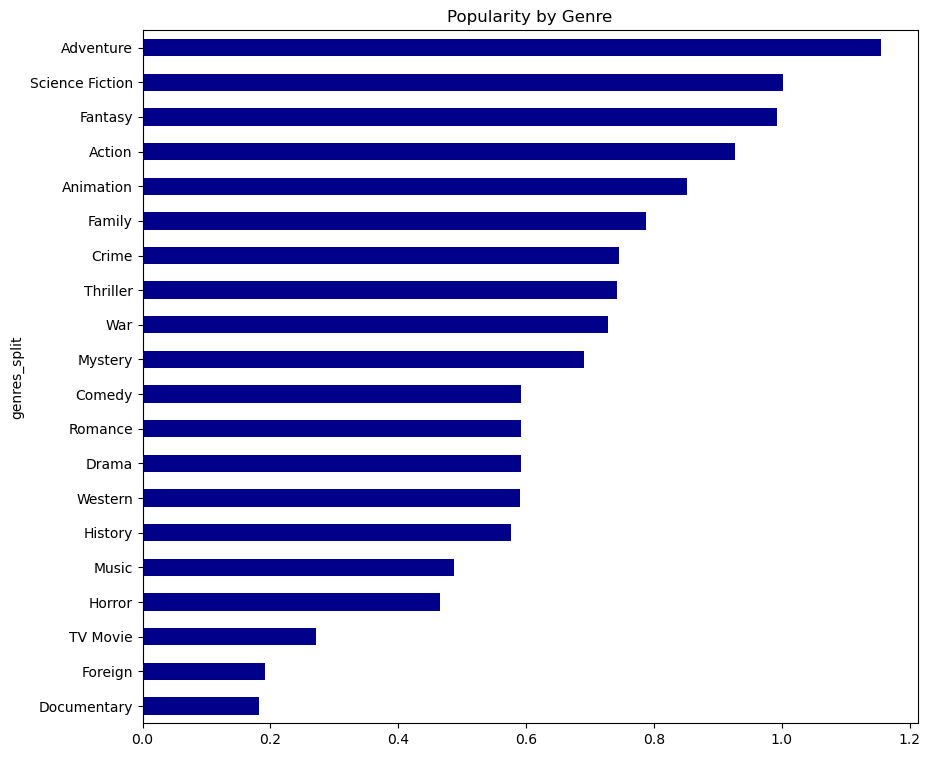

In [69]:
genres_avg['popularity'].plot.barh(title = 'Popularity by Genre', color = 'Darkblue', figsize = (10,9))

4. Which genres have highest number of movies with an voting avg. >= 8?

In [70]:
movies_genre

,popularity,budget,revenue,original_title,runtime,release_date,vote_count,vote_average,profit,genres_split
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.500000,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.500000,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.500000,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,5562,6.500000,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,5/13/15,6185,7.100000,228436354,Action
...,...,...,...,...,...,...,...,...,...,...
10863,0.065141,0,0,Beregis Avtomobilya,94,1/1/66,11,6.500000,0,Mystery
10863,0.065141,0,0,Beregis Avtomobilya,94,1/1/66,11,6.500000,0,Comedy
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,11/2/66,22,5.400000,0,Action
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,11/2/66,22,5.400000,0,Comedy


In [82]:
vote_fifty = movies_genre[(movies_genre['vote_count']>= 50) & (movies_genre['vote_average']>= 8)]
vote_zero =   movies_genre[movies_genre['vote_average']>= 8]

In [87]:
genres_vote = pd.DataFrame(vote_fifty.groupby('genres_split').vote_average.nunique()).sort_values('vote_average', ascending = True)

In [88]:
genres_vote

,vote_average
genres_split,
Fantasy,1
Science Fiction,1
Animation,1
Mystery,1
Horror,1
Family,1
Romance,2
Music,2
History,2


<Axes: title={'center': 'Vote Average by Genre'}, ylabel='genres_split'>

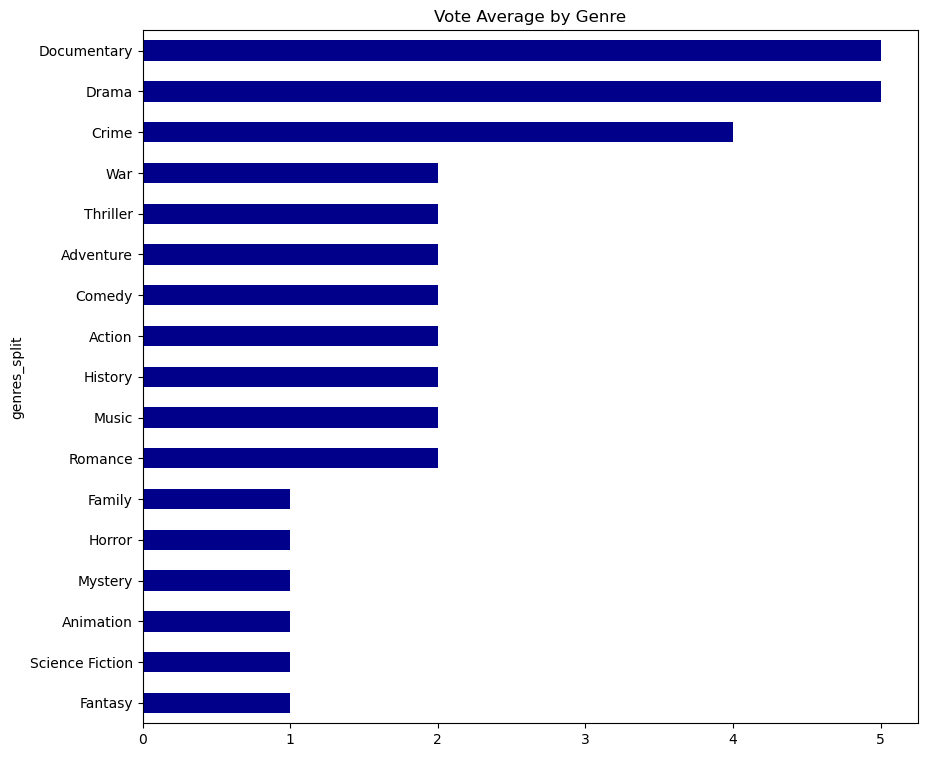

In [90]:
genres_vote['vote_average'].plot.barh(title = 'Vote Average by Genre', color = 'Darkblue', figsize = (10,9))

### Research Hypotheses

1. The best movies according to vote avg. return high profit and revenue.

In [98]:
movies.dropna(subset = ['genres'], inplace = True)
movies['profit'] = movies['revenue'] - movies['budget']
movies_genre = movies[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres', 'release_date', 'vote_count', 'vote_average', 'profit']]

In [99]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.500000,1363528810
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.100000,228436354
2,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.300000,185238201
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.500000,1868178225
4,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.300000,1316249360


In [101]:
movies_counted = movies_genre[movies_genre['vote_count'] >= 50]
movies_counted.corr(method = 'spearman')

/var/folders/mm/dk0qprd53tb6f0y8g20c97vr0000gn/T/ipykernel_72803/3319306841.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  movies_counted.corr(method = 'spearman')


,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.000000,0.484838,0.588588,0.230285,0.768870,0.189328,0.498078
budget,0.484838,1.000000,0.714566,0.359824,0.554290,-0.044236,0.333998
revenue,0.588588,0.714566,1.000000,0.341570,0.682540,0.112413,0.842196
runtime,0.230285,0.359824,0.341570,1.000000,0.263232,0.286280,0.212172
vote_count,0.768870,0.554290,0.682540,0.263232,1.000000,0.285173,0.583578
vote_average,0.189328,-0.044236,0.112413,0.286280,0.285173,1.000000,0.199008
profit,0.498078,0.333998,0.842196,0.212172,0.583578,0.199008,1.000000


<Axes: xlabel='vote_average', ylabel='revenue'>

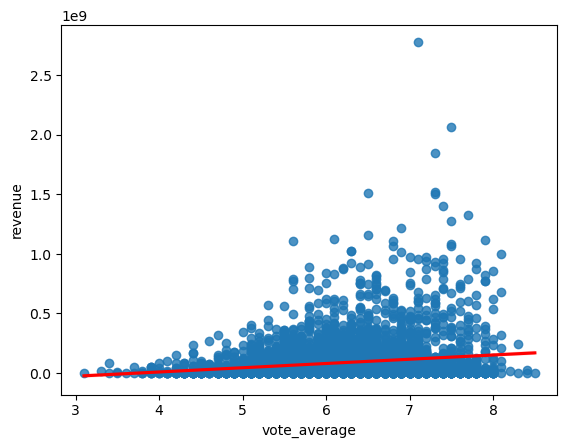

In [106]:
sns.regplot(x = 'vote_average', y= 'revenue', data=movies_counted, line_kws= {"color":'red'})

2. The best movies according to popularity return high profit and revenue.

In [107]:
movies_counted.corr(method= 'spearman')

/var/folders/mm/dk0qprd53tb6f0y8g20c97vr0000gn/T/ipykernel_72803/3024166067.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  movies_counted.corr(method= 'spearman')


,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.000000,0.484838,0.588588,0.230285,0.768870,0.189328,0.498078
budget,0.484838,1.000000,0.714566,0.359824,0.554290,-0.044236,0.333998
revenue,0.588588,0.714566,1.000000,0.341570,0.682540,0.112413,0.842196
runtime,0.230285,0.359824,0.341570,1.000000,0.263232,0.286280,0.212172
vote_count,0.768870,0.554290,0.682540,0.263232,1.000000,0.285173,0.583578
vote_average,0.189328,-0.044236,0.112413,0.286280,0.285173,1.000000,0.199008
profit,0.498078,0.333998,0.842196,0.212172,0.583578,0.199008,1.000000


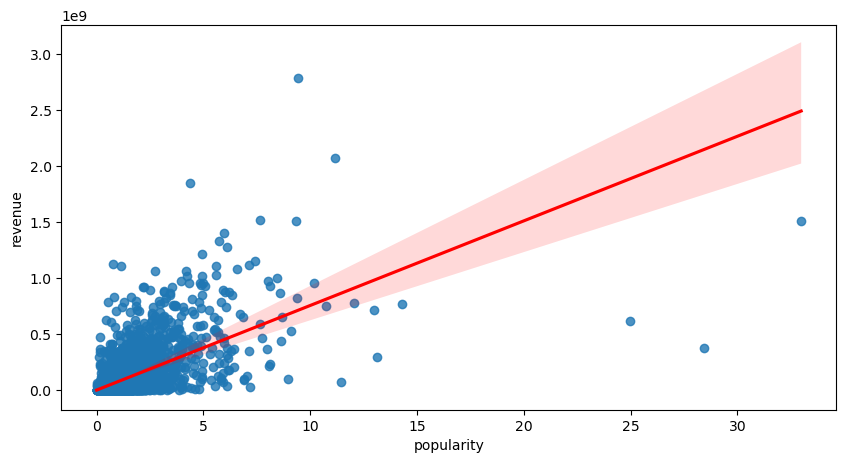

In [111]:
plt.figure(figsize = (10,5))
sns.regplot(x = 'popularity', y= 'revenue', data=movies_counted, line_kws= {"color":'red'})

plt.show()

3. Highly budgetedd movies return high profit.

In [112]:
movies_counted.head()

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.500000,1363528810
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.100000,228436354
2,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.300000,185238201
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.500000,1868178225
4,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.300000,1316249360


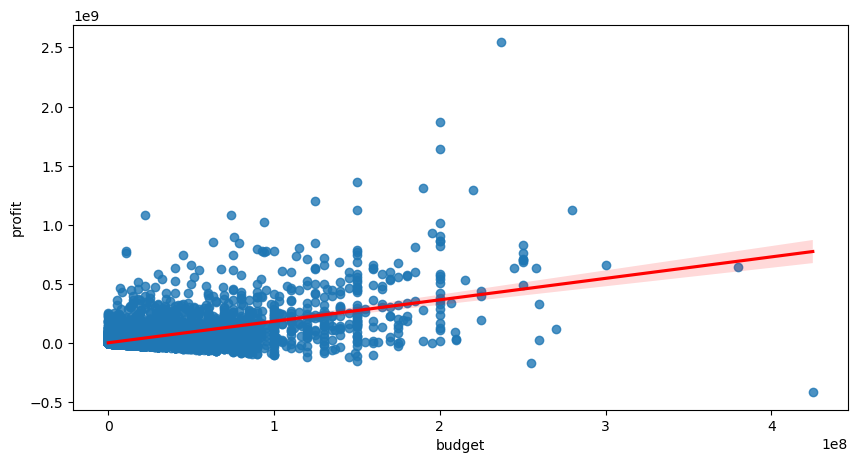

In [115]:
plt.figure(figsize = (10,5))
sns.regplot(x = 'budget', y= 'profit', data=movies_counted, line_kws= {"color":'red'})

plt.show()

4. Highly budgeted movies have a high popularity.

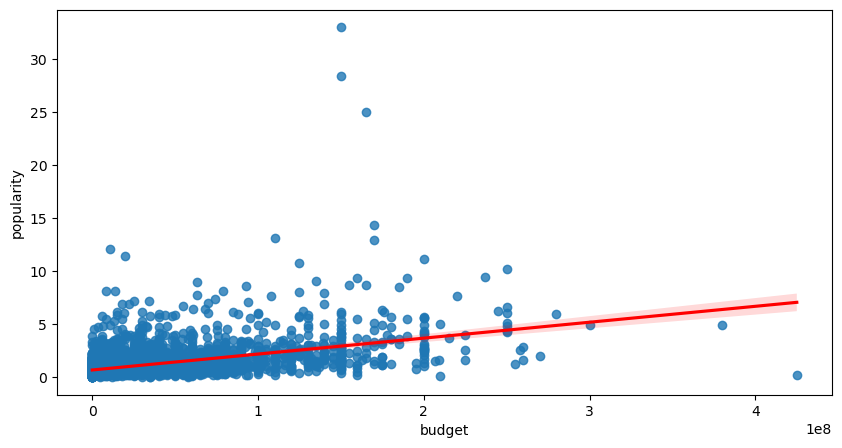

In [116]:
plt.figure(figsize = (10,5))
sns.regplot(x = 'budget', y= 'popularity', data=movies_counted, line_kws= {"color":'red'})

plt.show()

In [121]:
movies_genre.head()

,popularity,budget,revenue,original_title,runtime,release_year,vote_count,vote_average,profit,genres_split
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,2015,5562,6.500000,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,2015,6185,7.100000,228436354,Action


5. Lets additionally look at the profit per genre per year

In [124]:
time_genre = pd.DataFrame(movies_genre.groupby(['release_year', 'genres_split'])['profit'].mean())

In [125]:
time_genre

profit
release_year genres_split                   
1960         Action           6363125.000000
             Adventure         431000.000000
             Comedy           5258750.000000
             Crime                  0.000000
             Drama            8245619.384615
...                                      ...
2015         Science Fiction 83321303.523256
             TV Movie         -150000.000000
             Thriller        32869106.847953
             War             54677314.333333
             Western         72856619.000000

[1049 rows x 1 columns]

In [126]:
# lets pivot, so that the years are columns

In [128]:
final_genre = pd.pivot_table(time_genre, values = 'profit', index = ['genres_split'], columns = ['release_year'])

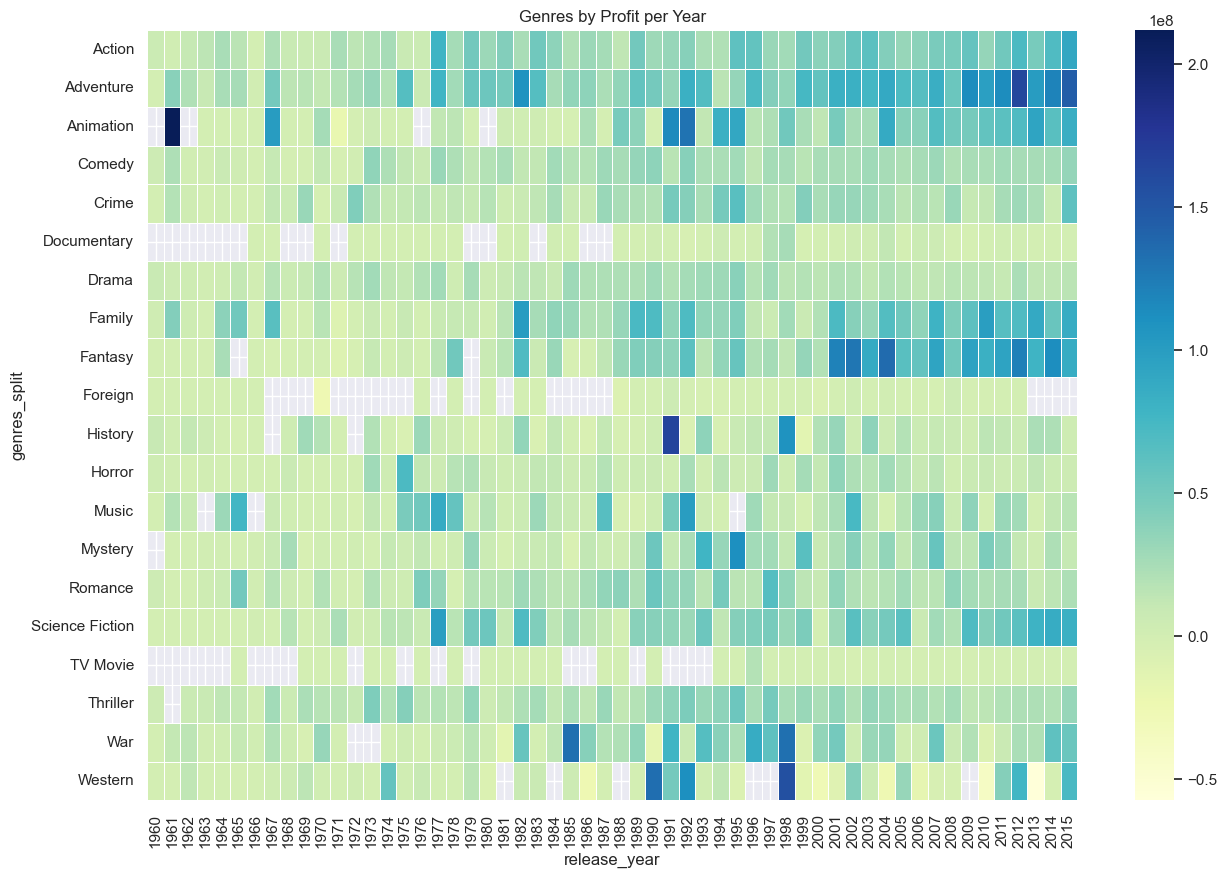

In [132]:
sns.set(rc= {'figure.figsize':(15,10)})
sns.heatmap(final_genre, cmap = 'YlGnBu', linewidths = .5)
plt.title('Genres by Profit per Year')
plt.show()